In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH = "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [3]:
df_anomalies = pd.read_csv(LABELS)

In [4]:
df_anomalies.info()
df_anomalies.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chan_id            82 non-null     str  
 1   spacecraft         82 non-null     str  
 2   anomaly_sequences  82 non-null     str  
 3   class              82 non-null     str  
 4   num_values         82 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.3 KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

From now on, we will use "channel" as equivalence of "feature" of each telemtry, which should not be confuse with "channel_id" of the labels dataset, which is referred to telemetry itself.

In [5]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Selecting only SMAP spacecraft, we have 54 telemetries, we probably should work with one at the time. Let's see how an anomaly is made:

In [69]:
np.random.seed(26)
telemetry_pos = np.random.randint(0,54)
print(telemetry_pos)

telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(telemetry_name)

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')
print(test_data.shape)

53
A-9
(8434, 25)


In [ ]:
anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(anomaly)

anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1]) #just to plot

[[4569 8433]]


We visualize only three channels out of 25

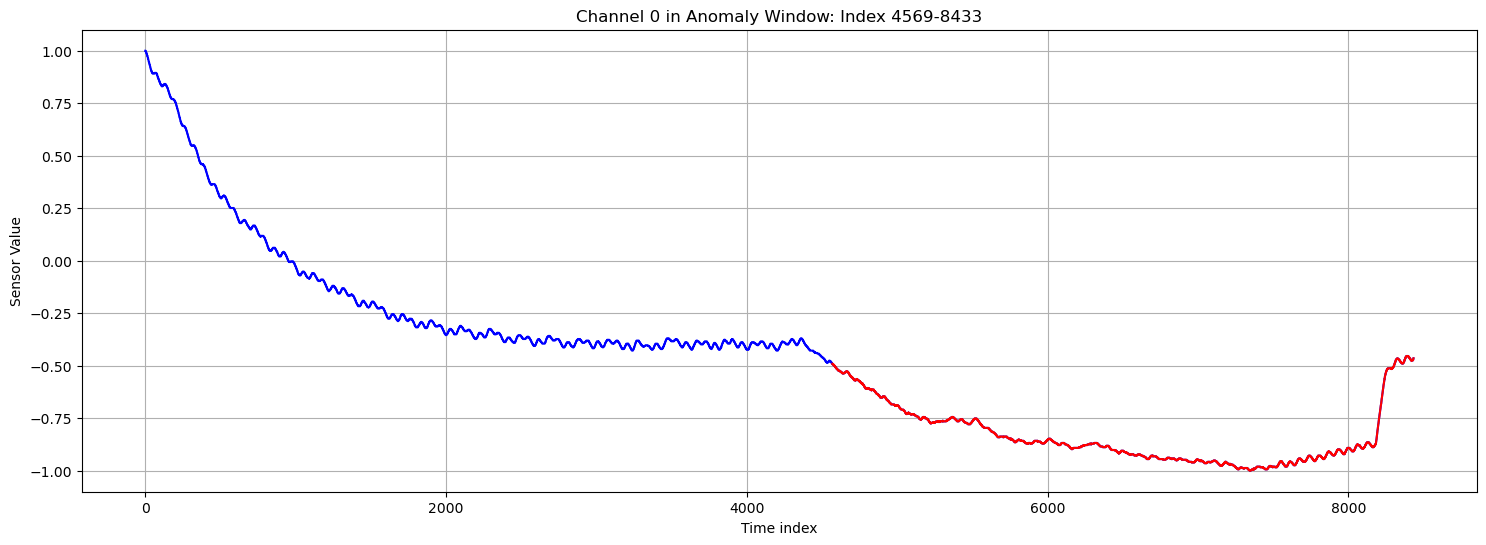

In [74]:
plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This is a **contextual** anomaly as an anomalous trend appears in telemeyry.

***PREPROCESSING***

For debug purposes, we start working with first channel (telemetry) of the training set, which is A-1, then we will extend.

In [96]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())
channel_id = smap_channels_ids[0]
print('channel:',channel_id)

X_train_raw = np.load(TRAIN_PATH + '/' + channel_id + '.npy')
print('Shape:',X_train_raw.shape)
print('Dtype:',X_train_raw.dtype)

channel: A-1
Shape: (2880, 25)
Dtype: float64


In [97]:
def check_array(X, name="X"):
    print(f"\n{name}")
    print('-' * 50)
    print("Shape:", X.shape)
    print("Dtype:", X.dtype)

    print("NaN count:", np.isnan(X).sum())
    print("Inf count:", np.isinf(X).sum())

    print("Min:", np.nanmin(X))
    print("Max:", np.nanmax(X))
    print("Mean:", np.nanmean(X))
    print("Std:", np.nanstd(X))

    feature_std = np.nanstd(X, axis=0)
    constant_features = np.where(feature_std == 0)[0]

    print("Number of constant features:", len(constant_features))
    if len(constant_features) > 0:
        print("Constant feature indices:", constant_features)

    print('-' * 50)

In [98]:
check_array(X_train_raw,f"Train {channel_id}")


Train A-1
--------------------------------------------------
Shape: (2880, 25)
Dtype: float64
NaN count: 0
Inf count: 0
Min: 0.0
Max: 1.0
Mean: 0.06165444444444444
Std: 0.24044378537340355
Number of constant features: 6
Constant feature indices: [10 12 15 16 23 24]
--------------------------------------------------


We extend to all channels (telemetries) and we cerate a dataframe summarizing.

In [99]:
train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.nanstd(X, axis=0) #std among columns, nanstd ignores nan val
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training set shows that the data are generally clean from a missing-value perspective. No NaN or infinite values were found across the considered telemetry channels, so no imputation or removal of corrupted samples is required at this stage.

However, the dataset presents some relevant preprocessing issues. First, the telemetry streams have *different temporal* lengths: most channels contain around 2600–2880 time steps, while some channels are much shorter. This affects the windowing procedure, because shorter series generate fewer training windows and may be less informative for sequence-based models.

Second, all channels have 25 features, but several of these features *are constant over time* within each channel. In some cases, only a few features are constant, while in others almost all features do not vary. This is important because **constant features do not carry temporal information and may unnecessarily increase the dimensionality of the input**. They can also affect scaling and model training if not handled explicitly. --> `PCA`

A special case is represented by channels such as `D-12` and `D-13`, where all 25 features are constant over time. This does not necessarily mean that the whole matrix contains a single repeated value: different columns may have different constant values. However, from a temporal modeling perspective, these channels contain no dynamic information in the training set, and therefore require special attention.

In [100]:
train_summary_df.describe()

,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
count,54.000000,54.0,54.0,54.0,54.000000,54.000000,54.000000,54.000000,54.000000
mean,2555.629630,25.0,0.0,0.0,10.388889,-0.857037,0.962963,0.005461,0.200148
std,656.221784,0.0,0.0,0.0,5.137420,0.333747,0.190626,0.027075,0.041398
min,312.000000,25.0,0.0,0.0,6.000000,-1.000000,0.000000,-0.040000,0.074036
25%,2596.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,-0.016257,0.175010
50%,2851.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,0.003124,0.201878
75%,2880.000000,25.0,0.0,0.0,12.750000,-1.000000,1.000000,0.023131,0.240640
max,2881.000000,25.0,0.0,0.0,25.000000,0.000000,1.000000,0.063826,0.252260


The preprocessing pipeline is applied independently to each SMAP telemetry channel. 
First, the original training sequence is split into training and validation subsets using a temporal split, without shuffling, in order to avoid temporal leakage. Constant features are detected only on the training subset and then removed from both training and validation data. This avoids using information from the validation period during feature selection.

After removing constant features, the remaining variables are standardized using a StandardScaler fitted only on the training subset. The same transformation is then applied to the validation subset. Optionally, PCA can be fitted on the standardized training data and applied to validation data, in order to reduce dimensionality while preserving a fixed fraction of the variance.

Finally, both training and validation sequences are converted into overlapping temporal windows, which represent the input format required by sequence-based reconstruction or forecasting models.

In [101]:
def temporal_train_val_split(X, val_ratio=0.2):
    """
    Temporal split: first part for training, last part for validation.
    """
    split_idx = int(len(X) * (1 - val_ratio))
    X_train = X[:split_idx]
    X_val = X[split_idx:]
    
    return X_train, X_val

In [102]:
def make_windows(X, window_size=30, stride=1):
    """
    Convert a time series X of shape (T, d)
    into windows of shape (n_windows, window_size, d).
    """
    if len(X) < window_size:
        return None
    
    windows = []
    
    for start in range(0, len(X) - window_size + 1, stride):
        end = start + window_size
        windows.append(X[start:end])
    
    return np.stack(windows)

In [ ]:
def preprocess_single_channel(
    channel_id,
    train_path,
    val_ratio=0.2,
    window_size=30,
    stride=1,
    drop_constant_features=True,
    use_pca=False,
    pca_variance=0.95
):
    # -------------------------
    # Load raw training sequence
    # -------------------------
    path = train_path + "/" + channel_id + ".npy"
    X_raw = np.load(path)
    
    # -------------------------
    # Basic checks
    # -------------------------
    nan_count = np.isnan(X_raw).sum()
    inf_count = np.isinf(X_raw).sum()
    
    if nan_count > 0:
        raise ValueError(f"{channel_id}: NaN values found.")
    
    if inf_count > 0:
        raise ValueError(f"{channel_id}: infinite values found.")
    
    # -------------------------
    # Temporal train/validation split
    # -------------------------
    X_train_raw, X_val_raw = temporal_train_val_split(X_raw, val_ratio=val_ratio)
    
    # -------------------------
    # Detect constant features on TRAIN only
    # -------------------------
    feature_std_train = np.std(X_train_raw, axis=0)
    constant_mask = feature_std_train == 0
    keep_mask = ~constant_mask
    
    n_constant_features = int(constant_mask.sum())
    constant_feature_indices = np.where(constant_mask)[0]
    kept_feature_indices = np.where(keep_mask)[0]
    
    # If all features are constant, skip this channel
    if keep_mask.sum() == 0:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_all_features_constant",
            "raw_shape": X_raw.shape,
            "n_constant_features": n_constant_features,
            "constant_feature_indices": constant_feature_indices,
        }
    
    # -------------------------
    # Drop constant features
    # -------------------------
    if drop_constant_features:
        X_train_raw = X_train_raw[:, keep_mask]
        X_val_raw = X_val_raw[:, keep_mask]
    else:
        kept_feature_indices = np.arange(X_raw.shape[1])
    
    # -------------------------
    # Scaling: fit only on train
    # -------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_val_scaled = scaler.transform(X_val_raw)
    
    # -------------------------
    # Optional PCA: fit only on train
    # -------------------------
    pca = None
    
    if use_pca:
        pca = PCA(n_components=pca_variance)
        X_train_processed = pca.fit_transform(X_train_scaled)
        X_val_processed = pca.transform(X_val_scaled)
        n_components = pca.n_components_
        explained_variance = float(pca.explained_variance_ratio_.sum())
    else:
        X_train_processed = X_train_scaled
        X_val_processed = X_val_scaled
        n_components = X_train_processed.shape[1]
        explained_variance = None
    
    # -------------------------
    # Windowing
    # -------------------------
    X_train_win = make_windows(X_train_processed, window_size=window_size, stride=stride)
    X_val_win = make_windows(X_val_processed, window_size=window_size, stride=stride)
    
    if X_train_win is None or X_val_win is None:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_too_short_after_split",
            "raw_shape": X_raw.shape,
            "train_shape": X_train_processed.shape,
            "val_shape": X_val_processed.shape,
        }
    
    # -------------------------
    # Output dictionary
    # -------------------------
    data = {
        "X_train": X_train_win,
        "X_val": X_val_win,
        "scaler": scaler,
        "pca": pca,
        "kept_feature_indices": kept_feature_indices,
        "constant_feature_indices": constant_feature_indices,
    }
    
    info = {
        "channel_id": channel_id,
        "status": "ok",
        "raw_shape": X_raw.shape,
        "train_raw_shape": X_train_raw.shape,
        "val_raw_shape": X_val_raw.shape,
        "train_windows_shape": X_train_win.shape,
        "val_windows_shape": X_val_win.shape,
        "n_original_features": X_raw.shape[1],
        "n_constant_features": n_constant_features,
        "n_kept_features": len(kept_feature_indices),
        "use_pca": use_pca,
        "n_components_after_pca": n_components,
        "pca_explained_variance": explained_variance,
    }
    
    return data, info

We try first without PCA, then with PCA.

In [105]:
VAL_RATIO = 0.2
WINDOW_SIZE = 30
STRIDE = 1

USE_PCA = False          
PCA_VARIANCE = 0.95
DROP_CONSTANT_FEATURES = True

preprocessed_data = {}
preprocessing_summary = []

for ch in smap_channels_ids:
    data, info = preprocess_single_channel(
        channel_id=ch,
        train_path=TRAIN_PATH,
        val_ratio=VAL_RATIO,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        drop_constant_features=DROP_CONSTANT_FEATURES,
        use_pca=USE_PCA,
        pca_variance=PCA_VARIANCE
    )
    
    preprocessing_summary.append(info)
    
    if data is not None:
        preprocessed_data[ch] = data

preprocessing_summary_df = pd.DataFrame(preprocessing_summary)
preprocessing_summary_df

,channel_id,status,raw_shape,train_raw_shape,val_raw_shape,train_windows_shape,val_windows_shape,n_original_features,n_constant_features,n_kept_features,use_pca,n_components_after_pca,pca_explained_variance,constant_feature_indices
0,A-1,ok,"(2880, 25)","(2304, 19)","(576, 19)","(2275, 30, 19)","(547, 30, 19)",25.0,6,19.0,False,19.0,NaN,NaN
1,A-2,ok,"(2648, 25)","(2118, 18)","(530, 18)","(2089, 30, 18)","(501, 30, 18)",25.0,7,18.0,False,18.0,NaN,NaN
2,A-3,ok,"(2736, 25)","(2188, 18)","(548, 18)","(2159, 30, 18)","(519, 30, 18)",25.0,7,18.0,False,18.0,NaN,NaN
3,A-4,ok,"(2690, 25)","(2152, 18)","(538, 18)","(2123, 30, 18)","(509, 30, 18)",25.0,7,18.0,False,18.0,NaN,NaN
4,A-5,ok,"(705, 25)","(564, 11)","(141, 11)","(535, 30, 11)","(112, 30, 11)",25.0,14,11.0,False,11.0,NaN,NaN
5,A-6,ok,"(682, 25)","(545, 11)","(137, 11)","(516, 30, 11)","(108, 30, 11)",25.0,14,11.0,False,11.0,NaN,NaN
6,A-7,ok,"(2879, 25)","(2303, 10)","(576, 10)","(2274, 30, 10)","(547, 30, 10)",25.0,15,10.0,False,10.0,NaN,NaN
7,A-8,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 10)","(124, 30, 10)",25.0,15,10.0,False,10.0,NaN,NaN
8,A-9,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 10)","(124, 30, 10)",25.0,15,10.0,False,10.0,NaN,NaN
9,B-1,ok,"(2435, 25)","(1948, 12)","(487, 12)","(1919, 30, 12)","(458, 30, 12)",25.0,13,12.0,False,12.0,NaN,NaN
